In [1]:
import os
# replace this path with wherever find located latex
os.environ["PATH"] += ":/Users/yairmau/Library/TinyTeX/bin/universal-darwin"

In [2]:
import manim
from manim import *

Manim Community v0.20.1

[06/12/26 18:03:13] INFO                                                                   ]8;id=13399615;file:///Users/yairmau/.uv-envs/olympus/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=13399616;file:///Users/yairmau/.uv-envs/olympus/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/Users/yairmau/repos/mishmash/group_theory/media/images/grou                         
                             p_theory/SL2Diagram_ManimCE_v0.20.1.png'                                              
                                                                                                                   

                    INFO     Rendered SL2Diagram                                                       ]8;id=13399621;file:///Users/yairmau/.uv-envs/olympus/lib/python3.12/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=13399622;file:///Users/yairmau/.uv-envs/olympus/lib/python3.12/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 1 animations                                                                   

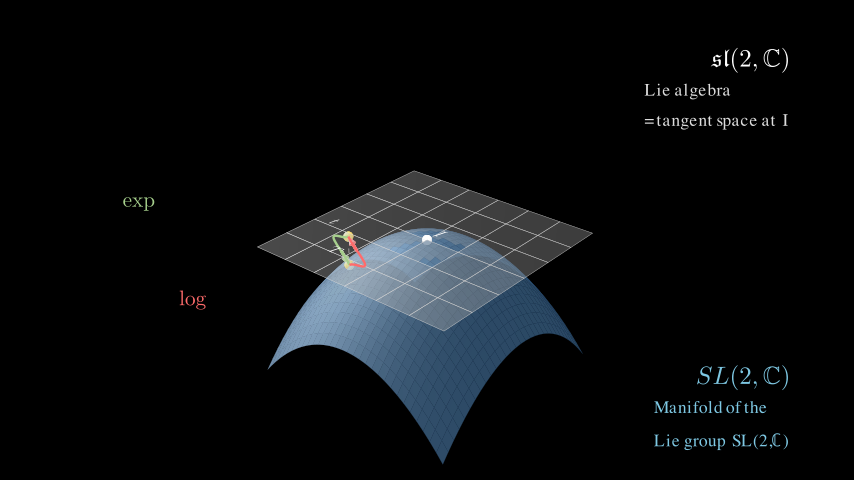

In [4]:
%%manim -ql --save_last_frame SL2Diagram

from manim import *
import numpy as np

class SL2Diagram(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=62 * DEGREES, theta=-50 * DEGREES, zoom=0.9)

        # ── MANIFOLD: downward paraboloid, apex at origin ───────────────────
        def manifold_fn(u, v):
            x = 2.2 * u
            y = 2.2 * v
            z = -0.28 * (x**2 + y**2)   # frowning paraboloid
            return np.array([x, y, z])

        manifold = Surface(
            manifold_fn,
            u_range=[-1, 1],
            v_range=[-1, 1],
            resolution=(30, 30),
        )
        manifold.set_style(
            fill_opacity=0.75,
            fill_color="#3a6186",
            stroke_width=0.25,
            stroke_color="#1a3a5c",
        )

        # ── TANGENT PLANE: horizontal at z=0, tangent at apex ──────────────
        TH = 0.0   # apex of paraboloid is at z=0, tangent plane is z=0

        tangent_plane = Surface(
            lambda u, v: np.array([2.2 * u, 2.2 * v, TH]),
            u_range=[-1, 1],
            v_range=[-1, 1],
            resolution=(6, 6),
        )
        tangent_plane.set_style(
            fill_opacity=0.38,
            fill_color="#888888",
            stroke_width=0.7,
            stroke_color="#aaaaaa",
        )

        # ── KEY POINTS ──────────────────────────────────────────────────────
        # Identity = apex of paraboloid = where tangent plane touches manifold
        I_pos = manifold_fn(0, 0)   # = [0, 0, 0]

        # A general group element T on the manifold (below tangent plane)
        T_pos = manifold_fn(-0.55, -0.38)
        # Its log t lives on the tangent plane directly above T
        t_pos = np.array([T_pos[0], T_pos[1], TH])

        def dot(pos, col):
            return Dot3D(pos, color=col, radius=0.09)

        I_dot = dot(I_pos, WHITE)
        T_dot = dot(T_pos, YELLOW)
        t_dot = dot(t_pos, YELLOW)

        # ── EXP / LOG CURVED PATHS ──────────────────────────────────────────
        def arc3d(start, end, bow, color):
            start, end, bow = np.array(start), np.array(end), np.array(bow)
            mid = (start + end) / 2 + bow
            curve = VMobject(stroke_color=color, stroke_width=4)
            curve.set_points_smoothly([start,
                                       start * 0.6 + mid * 0.4,
                                       mid,
                                       mid * 0.4 + end * 0.6,
                                       end])
            direction = end - (mid * 0.4 + end * 0.6)
            direction /= np.linalg.norm(direction) + 1e-8
            tip = Arrow3D(
                end - direction * 0.35, end,
                color=color, thickness=0.025,
                height=0.18, base_radius=0.06,
            )
            return VGroup(curve, tip)

        exp_arrow = arc3d(t_pos, T_pos, np.array([-0.6,  0.2, 0.0]), GREEN_B)
        log_arrow = arc3d(T_pos, t_pos, np.array([ 0.6, -0.2, 0.0]), "#ff6b6b")

        # ── DASHED VERTICAL LINE t -> T ─────────────────────────────────────
        dashed = DashedLine(t_pos, T_pos, color=GREY_B,
                            stroke_width=1.2, dash_length=0.12)

        # ── 3-D POINT LABELS ────────────────────────────────────────────────
        def lbl3d(tex, pos, shift):
            m = MathTex(tex, font_size=34)
            m.move_to(np.array(pos) + np.array(shift))
            return m

        lI = lbl3d("I",  I_pos, [ 0.28,  0.05,  0.20])
        lT = lbl3d("T",  T_pos, [-0.35,  0.00,  0.20])
        lt = lbl3d("t",  t_pos, [-0.35,  0.00,  0.20])

        # ── FIXED-IN-FRAME LABELS ────────────────────────────────────────────
        algebra_title = MathTex(r"\mathfrak{sl}(2,\mathbb{C})",
                                font_size=40, color=WHITE)
        algebra_sub   = Text("Lie algebra\n= tangent space at  I",
                             font_size=21, color=GREY_A, line_spacing=1.3)
        group_title   = MathTex(r"SL(2,\mathbb{C})",
                                font_size=40, color="#7ec8e3")
        group_sub     = Text("Manifold of the\nLie group  SL(2,ℂ)",
                             font_size=21, color="#7ec8e3", line_spacing=1.3)
        exp_lbl = MathTex(r"\exp", font_size=34, color=GREEN_B)
        log_lbl = MathTex(r"\log", font_size=34, color="#ff6b6b")

        algebra_title.to_corner(UR).shift(LEFT * 0.6 + DOWN * 0.3)
        algebra_sub.next_to(algebra_title, DOWN, buff=0.18).align_to(algebra_title, RIGHT)
        group_title.to_corner(DR).shift(LEFT * 0.6 + UP * 1.0)
        group_sub.next_to(group_title, DOWN, buff=0.18).align_to(group_title, RIGHT)
        exp_lbl.move_to(LEFT * 4.8 + UP * 0.6)
        log_lbl.move_to(LEFT * 3.9 + DOWN * 1.0)

        # ── ASSEMBLE ─────────────────────────────────────────────────────────
        self.add(manifold, tangent_plane)
        self.add(dashed)
        self.add(I_dot, T_dot, t_dot)
        self.add(exp_arrow, log_arrow)
        self.add(lI, lT, lt)

        self.add_fixed_in_frame_mobjects(
            algebra_title, algebra_sub,
            group_title, group_sub,
            exp_lbl, log_lbl,
        )

        self.wait(1)

In [1]:
import plotly.graph_objects as go
import numpy as np

# ── PARABOLOID MANIFOLD ─────────────────────────────────────────────────────
u = np.linspace(-1, 1, 60)
v = np.linspace(-1, 1, 60)
U, V = np.meshgrid(u, v)
X = 2.2 * U
Y = 2.2 * V
Z = -0.28 * (X**2 + Y**2)

# ── TANGENT PLANE at apex (z=0) ─────────────────────────────────────────────
tp = np.linspace(-1, 1, 6)
TP_U, TP_V = np.meshgrid(tp, tp)
TP_X = 2.2 * TP_U
TP_Y = 2.2 * TP_V
TP_Z = np.zeros_like(TP_X)

# ── KEY POINTS ───────────────────────────────────────────────────────────────
def manifold_fn(u, v):
    x = 2.2 * u
    y = 2.2 * v
    z = -0.28 * (x**2 + y**2)
    return np.array([x, y, z])

I_pos = manifold_fn(0, 0)
T_pos = manifold_fn(-0.55, -0.38)
t_pos = np.array([T_pos[0], T_pos[1], 0.0])

# ── EXP / LOG CURVED PATHS ───────────────────────────────────────────────────
def arc3d(start, end, bow, n=40):
    start, end, bow = np.array(start), np.array(end), np.array(bow)
    mid = (start + end) / 2 + bow
    t_vals = np.linspace(0, 1, n)
    # quadratic bezier
    pts = np.outer((1-t_vals)**2, start) + \
          np.outer(2*(1-t_vals)*t_vals, mid) + \
          np.outer(t_vals**2, end)
    return pts[:, 0], pts[:, 1], pts[:, 2]

exp_x, exp_y, exp_z = arc3d(t_pos, T_pos, np.array([-0.6,  0.2, 0.0]))
log_x, log_y, log_z = arc3d(T_pos, t_pos, np.array([ 0.6, -0.2, 0.0]))

# ── DASHED LINE t -> T ────────────────────────────────────────────────────────
dash_x = [t_pos[0], T_pos[0]]
dash_y = [t_pos[1], T_pos[1]]
dash_z = [t_pos[2], T_pos[2]]

# ── BUILD FIGURE ─────────────────────────────────────────────────────────────
fig = go.Figure()

# Manifold
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale=[[0, "#1a3a5c"], [1, "#5a91c6"]],
    opacity=0.75,
    showscale=False,
    name="SL(2,ℂ)"
))

# Tangent plane
fig.add_trace(go.Surface(
    x=TP_X, y=TP_Y, z=TP_Z,
    colorscale=[[0, "#666666"], [1, "#aaaaaa"]],
    opacity=0.38,
    showscale=False,
    name="sl(2,ℂ)"
))

# Exp arrow (green)
fig.add_trace(go.Scatter3d(
    x=exp_x, y=exp_y, z=exp_z,
    mode="lines",
    line=dict(color="green", width=5),
    name="exp"
))

# Log arrow (red)
fig.add_trace(go.Scatter3d(
    x=log_x, y=log_y, z=log_z,
    mode="lines",
    line=dict(color="#ff6b6b", width=5),
    name="log"
))

# Dashed vertical line
fig.add_trace(go.Scatter3d(
    x=dash_x, y=dash_y, z=dash_z,
    mode="lines",
    line=dict(color="grey", width=2, dash="dash"),
    name=""
))

# Points
points = {
    "I": I_pos,
    "T": T_pos,
    "t": t_pos,
}
for label, pos in points.items():
    fig.add_trace(go.Scatter3d(
        x=[pos[0]], y=[pos[1]], z=[pos[2]],
        mode="markers+text",
        marker=dict(size=6, color="white" if label == "I" else "yellow"),
        text=[f"<b>{label}</b>"],
        textposition="top center",
        textfont=dict(size=16, color="white"),
        showlegend=False,
    ))

# Labels for exp / log midpoints
for label, xs, ys, zs, col in [
    ("exp", exp_x, exp_y, exp_z, "lightgreen"),
    ("log", log_x, log_y, log_z, "#ff9999"),
]:
    mid = len(xs) // 2
    fig.add_trace(go.Scatter3d(
        x=[xs[mid]], y=[ys[mid]], z=[zs[mid]],
        mode="text",
        text=[f"<b>{label}</b>"],
        textfont=dict(size=15, color=col),
        showlegend=False,
    ))

# ── LAYOUT ────────────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text="SL(2,ℂ)  and its Lie algebra  sl(2,ℂ)",
        font=dict(size=18, color="white")
    ),
    paper_bgcolor="#111111",
    scene=dict(
        bgcolor="#111111",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        camera=dict(eye=dict(x=1.4, y=-1.8, z=1.0)),
        annotations=[
            dict(x=0, y=0, z=0.25,
                 text="sl(2,ℂ) — tangent plane at I",
                 showarrow=False, font=dict(color="lightgrey", size=13)),
            dict(x=0, y=0, z=-1.5,
                 text="SL(2,ℂ) — Lie group manifold",
                 showarrow=False, font=dict(color="#7ec8e3", size=13)),
        ]
    ),
    legend=dict(font=dict(color="white")),
    margin=dict(l=0, r=0, t=40, b=0),
    width=800, height=600,
)

fig.show()